In [29]:
#Importing necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [30]:
df = pd.read_csv(r"C:\Users\KIIT\Desktop\MLOPs\electricitybills\dataset\electricity_bill_dataset.csv")
df.head()

,Fan,Refrigerator,AirConditioner,Television,Monitor,MotorPump,Month,City,Company,MonthlyHours,TariffRate,ElectricityBill
0,16,23.0,2.0,6.0,1.0,0,10,Hyderabad,Tata Power Company Ltd.,384,8.4,3225.6
1,19,22.0,2.0,3.0,1.0,0,5,Vadodara,NHPC,488,7.8,3806.4
2,7,20.0,2.0,6.0,7.0,0,7,Shimla,Jyoti Structure,416,7.7,3203.2
3,7,22.0,3.0,21.0,1.0,0,6,Mumbai,Power Grid Corp,475,9.2,4370.0
4,11,23.0,2.0,11.0,1.0,0,2,Mumbai,Ratnagiri Gas and Power Pvt. Ltd. (RGPPL),457,9.2,4204.4


In [33]:
df.columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45345 entries, 0 to 45344
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Fan              45345 non-null  int64  
 1   Refrigerator     45345 non-null  float64
 2   AirConditioner   45345 non-null  float64
 3   Television       45345 non-null  float64
 4   Monitor          45345 non-null  float64
 5   MotorPump        45345 non-null  int64  
 6   Month            45345 non-null  int64  
 7   City             45345 non-null  object 
 8   Company          45345 non-null  object 
 9   MonthlyHours     45345 non-null  int64  
 10  TariffRate       45345 non-null  float64
 11  ElectricityBill  45345 non-null  float64
dtypes: float64(6), int64(4), object(2)
memory usage: 4.2+ MB


In [35]:
# data processing 
# data cleaning 
# checking of missing values
df.isna().sum()

Fan                0
Refrigerator       0
AirConditioner     0
Television         0
Monitor            0
MotorPump          0
Month              0
City               0
Company            0
MonthlyHours       0
TariffRate         0
ElectricityBill    0
dtype: int64

In [37]:
# checking of duplicate values
df.duplicated().sum()

np.int64(0)

In [39]:
# converting electricity bill datatype to float for uniformity
df['ElectricityBill'] = df['ElectricityBill'].astype(float)
df['ElectricityBill']

0        3225.6
1        3806.4
2        3203.2
3        4370.0
4        4204.4
          ...  
45340    6035.6
45341    4862.0
45342    5176.5
45343    5535.2
45344    3544.1
Name: ElectricityBill, Length: 45345, dtype: float64

In [40]:
# Feature Engineering
# Method to categorize seasons
def categorize_seasons(Month):
    if Month in [3, 4, 5]:
        return "Summer"
    elif Month in [6, 7, 8, 9]:
        return  "Monsoon"
    else:
        return  "Winter"

    
df['season'] = df['Month'].apply(categorize_seasons)

df.head()

,Fan,Refrigerator,AirConditioner,Television,Monitor,MotorPump,Month,City,Company,MonthlyHours,TariffRate,ElectricityBill,season
0,16,23.0,2.0,6.0,1.0,0,10,Hyderabad,Tata Power Company Ltd.,384,8.4,3225.6,Winter
1,19,22.0,2.0,3.0,1.0,0,5,Vadodara,NHPC,488,7.8,3806.4,Summer
2,7,20.0,2.0,6.0,7.0,0,7,Shimla,Jyoti Structure,416,7.7,3203.2,Monsoon
3,7,22.0,3.0,21.0,1.0,0,6,Mumbai,Power Grid Corp,475,9.2,4370.0,Monsoon
4,11,23.0,2.0,11.0,1.0,0,2,Mumbai,Ratnagiri Gas and Power Pvt. Ltd. (RGPPL),457,9.2,4204.4,Winter


In [45]:
# MonthlyCostPerHour
df['MonthlyCostPerHour'] = df['ElectricityBill'] / df['MonthlyHours']
print(df.head())

   Fan  Refrigerator  AirConditioner  Television  Monitor  MotorPump  Month  \
0   16          23.0             2.0         6.0      1.0          0     10   
1   19          22.0             2.0         3.0      1.0          0      5   
2    7          20.0             2.0         6.0      7.0          0      7   
3    7          22.0             3.0        21.0      1.0          0      6   
4   11          23.0             2.0        11.0      1.0          0      2   

        City                                    Company  MonthlyHours  \
0  Hyderabad                    Tata Power Company Ltd.           384   
1   Vadodara                                       NHPC           488   
2     Shimla                            Jyoti Structure           416   
3     Mumbai                            Power Grid Corp           475   
4     Mumbai  Ratnagiri Gas and Power Pvt. Ltd. (RGPPL)           457   

   TariffRate  ElectricityBill  MonthlyCostPerHour  
0         8.4           3225.6   

In [46]:
print(df.describe())

                Fan  Refrigerator  AirConditioner    Television       Monitor  \
count  45345.000000  45345.000000    45345.000000  45345.000000  45345.000000   
mean      13.990694     21.705458        1.503959     12.502635      2.865057   
std        5.470816      1.672575        1.115482      5.756007      3.894933   
min        5.000000     17.000000        0.000000      3.000000      1.000000   
25%        9.000000     22.000000        1.000000      7.000000      1.000000   
50%       14.000000     22.000000        2.000000     13.000000      1.000000   
75%       19.000000     23.000000        2.000000     17.000000      1.000000   
max       23.000000     23.000000        3.000000     22.000000     12.000000   

       MotorPump         Month  MonthlyHours    TariffRate  ElectricityBill  \
count    45345.0  45345.000000  45345.000000  45345.000000     45345.000000   
mean         0.0      6.488058    515.083207      8.369648      4311.771307   
std          0.0      3.443252   

In [47]:
# Tariff Efficiency
df['TariffEfficiency'] = df['ElectricityBill'] / df['TariffRate']
df.head()

,Fan,Refrigerator,AirConditioner,Television,Monitor,MotorPump,Month,City,Company,MonthlyHours,TariffRate,ElectricityBill,MonthlyCostPerHour,TariffEfficiency
0,16,23.0,2.0,6.0,1.0,0,10,Hyderabad,Tata Power Company Ltd.,384,8.4,3225.6,8.4,384.0
1,19,22.0,2.0,3.0,1.0,0,5,Vadodara,NHPC,488,7.8,3806.4,7.8,488.0
2,7,20.0,2.0,6.0,7.0,0,7,Shimla,Jyoti Structure,416,7.7,3203.2,7.7,416.0
3,7,22.0,3.0,21.0,1.0,0,6,Mumbai,Power Grid Corp,475,9.2,4370.0,9.2,475.0
4,11,23.0,2.0,11.0,1.0,0,2,Mumbai,Ratnagiri Gas and Power Pvt. Ltd. (RGPPL),457,9.2,4204.4,9.2,457.0


In [71]:
# Total Appliance Usage
df['TotalApplianceHours'] = df[['Fan', 'Refrigerator', 'AirConditioner', 'Television', 'Monitor', 'MotorPump']].sum(axis=1)
df.head()

,Fan,Refrigerator,AirConditioner,Television,Monitor,MotorPump,Month,City,Company,MonthlyHours,...,TariffEfficiency,TotalApplianceHours,Fan_Contribution,Refrigerator_Contribution,AirConditioner_Contribution,Television_Contribution,Monitor_Contribution,MotorPump_Contribution,UsageCategory,TotalConsumption
0,16,23.0,2.0,6.0,1.0,0,10,Hyderabad,Tata Power Company Ltd.,384,...,384.0,48.0,33.333333,47.916667,4.166667,12.500000,2.083333,0.0,Medium,48.0
1,19,22.0,2.0,3.0,1.0,0,5,Vadodara,NHPC,488,...,488.0,47.0,40.425532,46.808511,4.255319,6.382979,2.127660,0.0,Medium,47.0
3,7,22.0,3.0,21.0,1.0,0,6,Mumbai,Power Grid Corp,475,...,475.0,54.0,12.962963,40.740741,5.555556,38.888889,1.851852,0.0,Medium,54.0
4,11,23.0,2.0,11.0,1.0,0,2,Mumbai,Ratnagiri Gas and Power Pvt. Ltd. (RGPPL),457,...,457.0,48.0,22.916667,47.916667,4.166667,22.916667,2.083333,0.0,Medium,48.0
5,13,22.0,0.0,18.0,1.0,0,6,Ratnagiri,Adani Power Ltd.,471,...,471.0,54.0,24.074074,40.740741,0.000000,33.333333,1.851852,0.0,Medium,54.0


In [49]:
# Percentage Contribution of Each Appliance
appliances = ['Fan', 'Refrigerator', 'AirConditioner', 'Television', 'Monitor', 'MotorPump']
for appliance in appliances:
    df[f'{appliance}_Contribution'] = (df[appliance] / df['TotalApplianceHours']) * 100
df.head()

,Fan,Refrigerator,AirConditioner,Television,Monitor,MotorPump,Month,City,Company,MonthlyHours,...,ElectricityBill,MonthlyCostPerHour,TariffEfficiency,TotalApplianceHours,Fan_Contribution,Refrigerator_Contribution,AirConditioner_Contribution,Television_Contribution,Monitor_Contribution,MotorPump_Contribution
0,16,23.0,2.0,6.0,1.0,0,10,Hyderabad,Tata Power Company Ltd.,384,...,3225.6,8.4,384.0,48.0,33.333333,47.916667,4.166667,12.500000,2.083333,0.0
1,19,22.0,2.0,3.0,1.0,0,5,Vadodara,NHPC,488,...,3806.4,7.8,488.0,47.0,40.425532,46.808511,4.255319,6.382979,2.127660,0.0
2,7,20.0,2.0,6.0,7.0,0,7,Shimla,Jyoti Structure,416,...,3203.2,7.7,416.0,42.0,16.666667,47.619048,4.761905,14.285714,16.666667,0.0
3,7,22.0,3.0,21.0,1.0,0,6,Mumbai,Power Grid Corp,475,...,4370.0,9.2,475.0,54.0,12.962963,40.740741,5.555556,38.888889,1.851852,0.0
4,11,23.0,2.0,11.0,1.0,0,2,Mumbai,Ratnagiri Gas and Power Pvt. Ltd. (RGPPL),457,...,4204.4,9.2,457.0,48.0,22.916667,47.916667,4.166667,22.916667,2.083333,0.0


In [50]:
# Usage Category
def categorize_usage(bill):
    if bill < 2500:
        return 'Low'
    elif  2501 <= bill <= 5000 :
        return 'Medium'
    else:
        return 'High'

df['UsageCategory'] = df['ElectricityBill'].apply(categorize_usage)
df.head(15)

,Fan,Refrigerator,AirConditioner,Television,Monitor,MotorPump,Month,City,Company,MonthlyHours,...,MonthlyCostPerHour,TariffEfficiency,TotalApplianceHours,Fan_Contribution,Refrigerator_Contribution,AirConditioner_Contribution,Television_Contribution,Monitor_Contribution,MotorPump_Contribution,UsageCategory
0,16,23.0,2.0,6.0,1.0,0,10,Hyderabad,Tata Power Company Ltd.,384,...,8.4,384.0,48.0,33.333333,47.916667,4.166667,12.500000,2.083333,0.0,Medium
1,19,22.0,2.0,3.0,1.0,0,5,Vadodara,NHPC,488,...,7.8,488.0,47.0,40.425532,46.808511,4.255319,6.382979,2.127660,0.0,Medium
2,7,20.0,2.0,6.0,7.0,0,7,Shimla,Jyoti Structure,416,...,7.7,416.0,42.0,16.666667,47.619048,4.761905,14.285714,16.666667,0.0,Medium
3,7,22.0,3.0,21.0,1.0,0,6,Mumbai,Power Grid Corp,475,...,9.2,475.0,54.0,12.962963,40.740741,5.555556,38.888889,1.851852,0.0,Medium
4,11,23.0,2.0,11.0,1.0,0,2,Mumbai,Ratnagiri Gas and Power Pvt. Ltd. (RGPPL),457,...,9.2,457.0,48.0,22.916667,47.916667,4.166667,22.916667,2.083333,0.0,Medium
5,13,22.0,0.0,18.0,1.0,0,6,Ratnagiri,Adani Power Ltd.,471,...,7.4,471.0,54.0,24.074074,40.740741,0.000000,33.333333,1.851852,0.0,Medium
6,23,22.0,3.0,20.0,12.0,0,5,New Delhi,Kalpataru Power,755,...,8.5,755.0,80.0,28.750000,27.500000,3.750000,25.000000,15.000000,0.0,High
7,22,23.0,0.0,21.0,1.0,0,12,New Delhi,Adani Power Ltd.,492,...,8.5,492.0,67.0,32.835821,34.328358,0.000000,31.343284,1.492537,0.0,Medium
8,8,20.0,2.0,8.0,1.0,0,8,New Delhi,Orient Green,546,...,8.5,546.0,39.0,20.512821,51.282051,5.128205,20.512821,2.564103,0.0,Medium
9,10,23.0,0.0,18.0,7.0,0,1,Dahej,Sterlite Power Transmission Ltd,578,...,7.6,578.0,58.0,17.241379,39.655172,0.000000,31.034483,12.068966,0.0,Medium


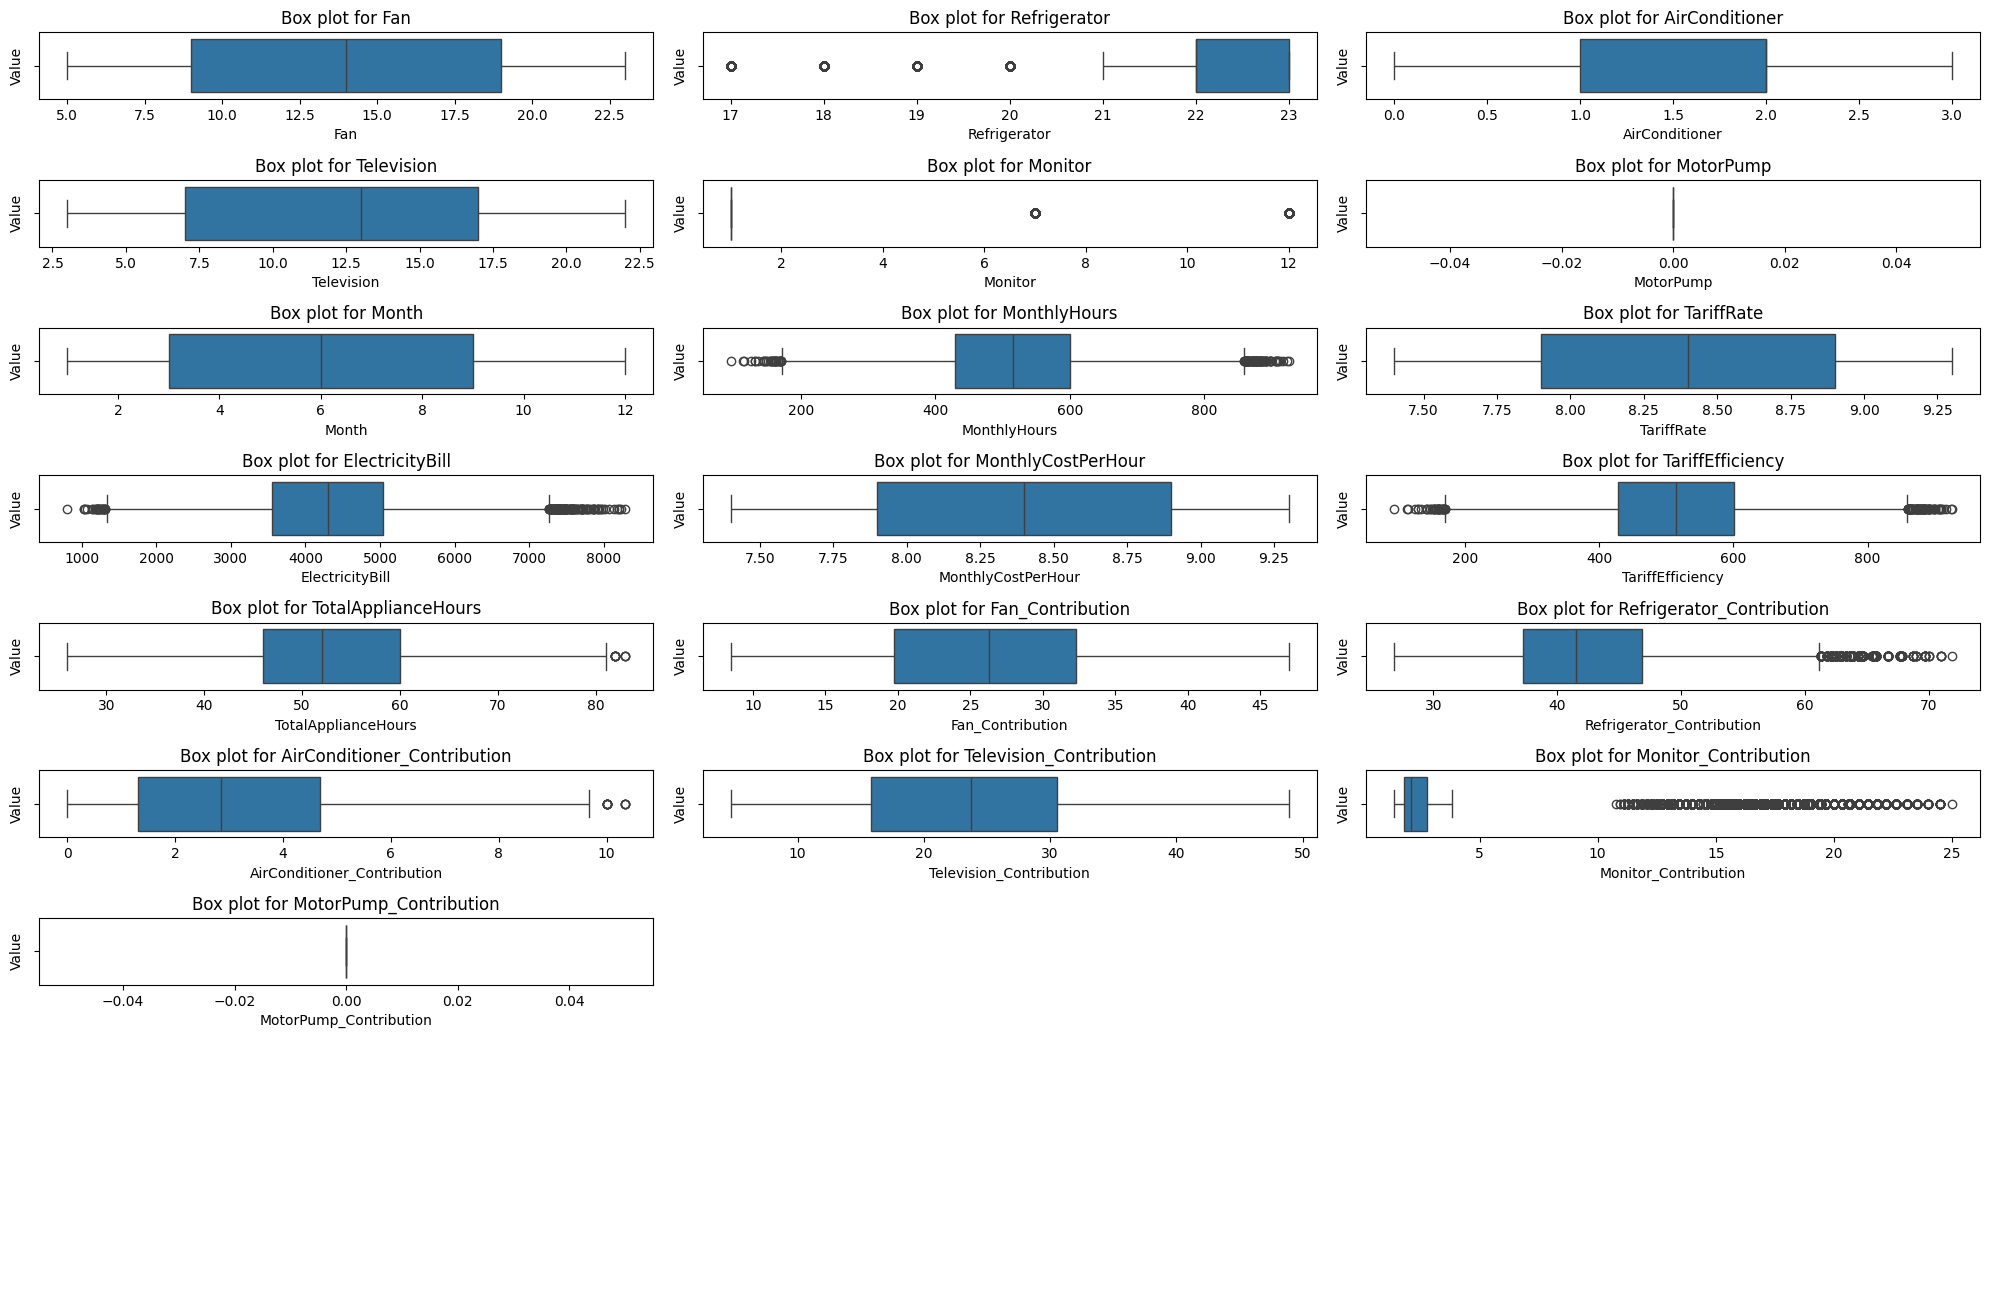

In [51]:
# Checking for outliers
#Only select numeric columns 
numeric_columns = df.select_dtypes(include=['float','integer']).columns[:]

# Grid layout
rows, cols = 9, 3
fig, axes = plt.subplots(rows, cols, figsize=(20, 13))

# Flatten 
axes = axes.flatten()

for i, column in enumerate(numeric_columns):
    sns.boxplot(x=df[column], ax = axes[i])
    axes[i].set_title(f"Box plot for {column}")
    axes[i].set_xlabel(column)
    axes[i].set_ylabel('Value')
    
# Hide empty subplots 
for j in range(i + 1, rows * cols):
    axes[j].axis('off')
    
plt.tight_layout()
plt.show()

In [52]:
# Dropping outliers
# Create a copy of the data
data_copy = df.copy()
# Select only numeric columns
numeric_data = data_copy.select_dtypes(include=['float','integer'])

# Calculate q1, q3, and IQR for numeric data only
q1 = numeric_data.quantile(0.20)  # .20
q3 = numeric_data.quantile(0.80)  # .80
IQR = q3 - q1

# Lower and upper bounds for identifying outliers
lower_bound = q1 - (1.5 * IQR)
upper_bound = q3 + (1.5 * IQR)

# Identify outliers in numeric columns
outliers_ = set()
for col in numeric_data.columns:
    outliers = numeric_data[(numeric_data[col] < lower_bound[col]) | (numeric_data[col] > upper_bound[col])]
    outliers_.update(outliers.index)

# Count number of rows before removing outliers
num_rows_before = len(data_copy)

# Remove rows with outliers from the original DataFrame (important!)
data_copy = data_copy.drop(index=outliers_)

# Num of rows after removing outliers
num_rows_after = len(data_copy)

# Number of rows removed
rows_removed = num_rows_before - num_rows_after

# Print the results
print(f"Number of rows before removing outliers: {num_rows_before}")
print(f"Number of rows after removing outliers: {num_rows_after}")
print(f"Number of rows removed: {rows_removed}")

df = data_copy.copy()

Number of rows before removing outliers: 45345
Number of rows after removing outliers: 34654
Number of rows removed: 10691



Average Consumption per Appliance (kWh):
        Appliance  Average Consumption (kWh)
1    Refrigerator                  21.928205
0             Fan                  14.305188
3      Television                  12.525105
2  AirConditioner                   1.513909
4         Monitor                   1.000000
5       MotorPump                   0.000000


C:\Users\KIIT\AppData\Local\Temp\ipykernel_32896\2138664698.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=appliance_consumption, x='Average Consumption (kWh)', y='Appliance', palette='coolwarm')


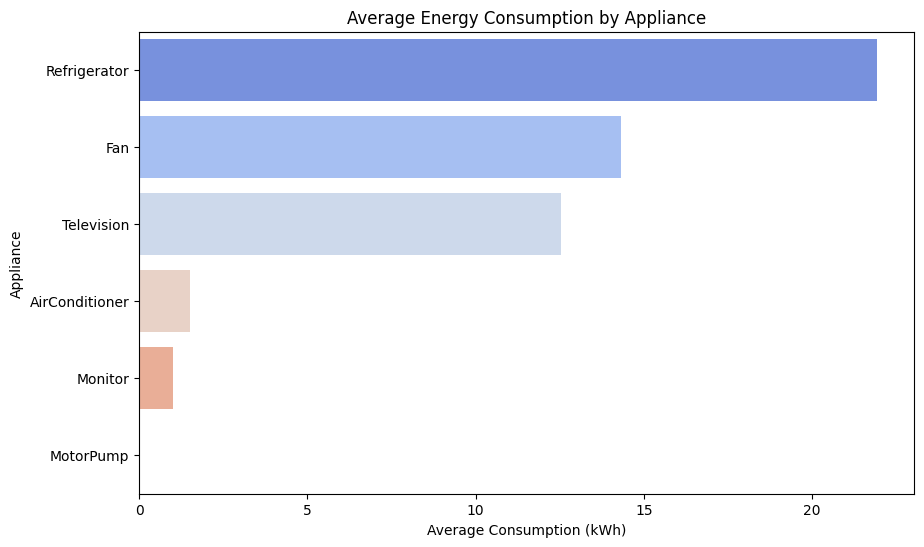

In [53]:
# --------- Objective 1: Appliance-Specific Energy Consumption ---------

# Calculate total consumption for each appliance
appliances = ['Fan', 'Refrigerator', 'AirConditioner', 'Television', 'Monitor', 'MotorPump']
appliance_consumption = df[appliances].mean().reset_index()
appliance_consumption.columns = ['Appliance', 'Average Consumption (kWh)']

# Sort appliances by average consumption
appliance_consumption = appliance_consumption.sort_values('Average Consumption (kWh)', ascending=False)
print("\nAverage Consumption per Appliance (kWh):")
print(appliance_consumption)

# Plot appliance-specific consumption
plt.figure(figsize=(10, 6))
sns.barplot(data=appliance_consumption, x='Average Consumption (kWh)', y='Appliance', palette='coolwarm')
plt.title('Average Energy Consumption by Appliance')
plt.xlabel('Average Consumption (kWh)')
plt.ylabel('Appliance')
plt.show()


Monthly Electricity Usage Trends:
    Month  ElectricityBill        Fan  Refrigerator  AirConditioner
0       1      4308.876709  14.338424     21.919125        1.502950
1       2      3831.561739  14.245913     21.922783        1.517913
2       3      4333.636459  14.344546     21.917431        1.529392
3       4      4177.856891  14.369806     21.964681        1.515928
4       5      4290.081589  14.377794     21.914154        1.473217
5       6      4135.277266  14.295330     21.954327        1.508929
6       7      4349.890323  14.440042     21.960028        1.505259
7       8      4310.891125  14.181911     21.937669        1.534553
8       9      4146.695658  14.102303     21.895066        1.524342
9      10      4320.486474  14.296188     21.903959        1.524560
10     11      4156.563990  14.275709     21.916297        1.517595
11     12      4325.006415  14.412055     21.933380        1.510398


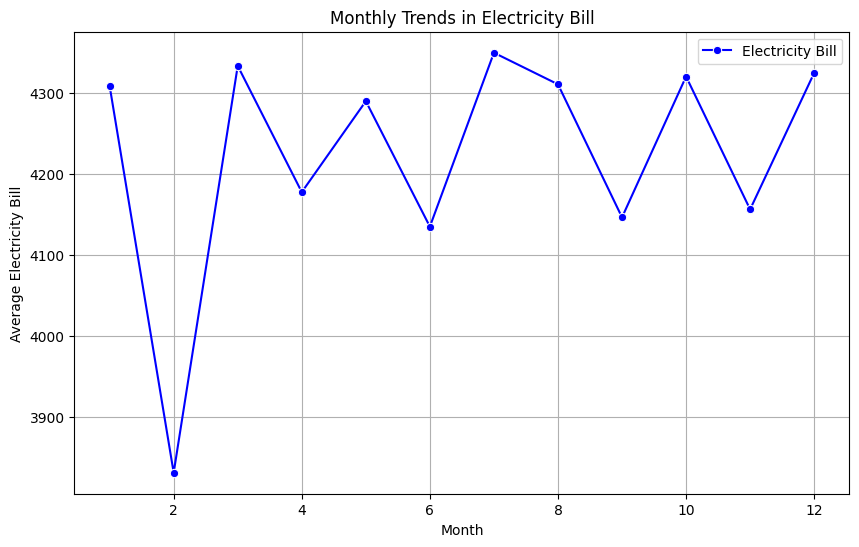

In [54]:
# --------- Objective 2: Monthly Electricity Usage Trends ---------

# Calculate average consumption and electricity bill by month
monthly_trends = df.groupby('Month')[['ElectricityBill', 'Fan', 'Refrigerator', 'AirConditioner']].mean().reset_index()
print("\nMonthly Electricity Usage Trends:")
print(monthly_trends)

# Plot total electricity bill over months
plt.figure(figsize=(10, 6))
sns.lineplot(data=monthly_trends, x='Month', y='ElectricityBill', marker='o', color='blue', label='Electricity Bill')
plt.title('Monthly Trends in Electricity Bill')
plt.xlabel('Month')
plt.ylabel('Average Electricity Bill')
plt.grid()
plt.legend()
plt.show()


City-Wise Electricity Usage and Billing:
           City  ElectricityBill        Fan  Refrigerator  AirConditioner
7        Mumbai      4680.156273  14.418358     21.933579        1.527214
9   Navi Mumbai      4673.726280  14.222372     21.880503        1.486523
12         Pune      4603.194137  14.501163     21.898092        1.494183
8        Nagpur      4510.086442  14.422160     21.972417        1.562412
1       Chennai      4454.878578  14.339102     21.949953        1.507951
6       Kolkata      4416.534247  14.269721     21.964100        1.502126
10    New Delhi      4296.993409  14.330455     21.913182        1.540909
5     Hyderabad      4213.700754  14.051441     21.938803        1.536142
4       Gurgaon      4203.189982  14.425657     21.957842        1.522665
11        Noida      4110.962628  14.328518     21.946878        1.486952
3     Faridabad      4082.198507  14.346902     21.924469        1.529625
0     Ahmedabad      3957.286049  14.292603     21.902154        1.468

C:\Users\KIIT\AppData\Local\Temp\ipykernel_32896\202645460.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=city_analysis, x='City', y='ElectricityBill', palette='viridis')


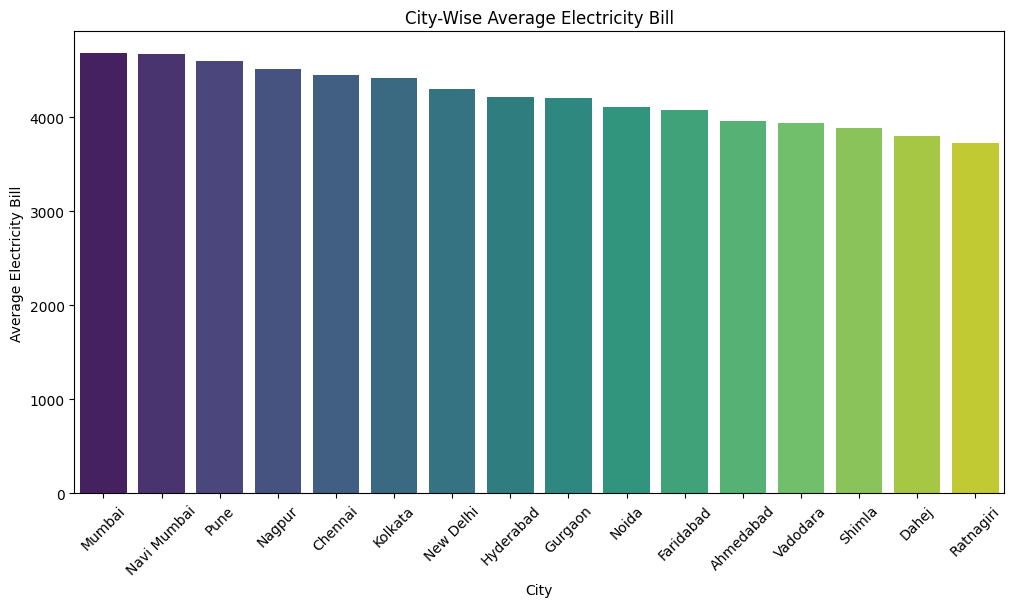

In [55]:
# --------- Objective 3: City-Wise Electricity Usage ---------

# Calculate average electricity consumption and bill by city
city_analysis = df.groupby('City')[['ElectricityBill', 'Fan', 'Refrigerator', 'AirConditioner']].mean().reset_index()
city_analysis = city_analysis.sort_values('ElectricityBill', ascending=False)
print("\nCity-Wise Electricity Usage and Billing:")
print(city_analysis)

# Plot city-wise electricity bills
plt.figure(figsize=(12, 6))
sns.barplot(data=city_analysis, x='City', y='ElectricityBill', palette='viridis')
plt.title('City-Wise Average Electricity Bill')
plt.xlabel('City')
plt.ylabel('Average Electricity Bill')
plt.xticks(rotation=45)
plt.show()

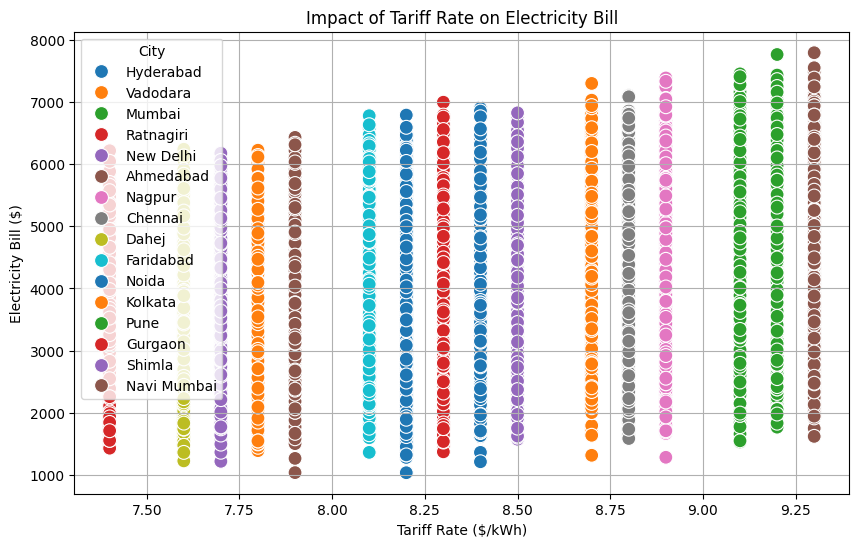


Correlation between Tariff Rate and Electricity Bill: 0.30


In [56]:
# --------- Objective 4: Impact of Tariff Rates ---------

# Analyze the relationship between TariffRate and ElectricityBill
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='TariffRate', y='ElectricityBill', hue='City', palette='tab10', s=100)
plt.title('Impact of Tariff Rate on Electricity Bill')
plt.xlabel('Tariff Rate ($/kWh)')
plt.ylabel('Electricity Bill ($)')
plt.grid()
plt.show()

# Correlation between TariffRate and ElectricityBill
correlation = df[['TariffRate', 'ElectricityBill']].corr().iloc[0, 1]
print(f"\nCorrelation between Tariff Rate and Electricity Bill: {correlation:.2f}")

In [57]:
df.columns

Index(['Fan', 'Refrigerator', 'AirConditioner', 'Television', 'Monitor',
       'MotorPump', 'Month', 'City', 'Company', 'MonthlyHours', 'TariffRate',
       'ElectricityBill', 'MonthlyCostPerHour', 'TariffEfficiency',
       'TotalApplianceHours', 'Fan_Contribution', 'Refrigerator_Contribution',
       'AirConditioner_Contribution', 'Television_Contribution',
       'Monitor_Contribution', 'MotorPump_Contribution', 'UsageCategory'],
      dtype='object')


Proportion of Total Electricity Consumption by Appliance:
        Appliance  Total Consumption (kWh)  Proportion (%)
1    Refrigerator                 759900.0       42.768042
0             Fan                 495732.0       27.900364
3      Television                 434045.0       24.428549
2  AirConditioner                  52463.0        2.952678
4         Monitor                  34654.0        1.950367
5       MotorPump                      0.0        0.000000


C:\Users\KIIT\AppData\Local\Temp\ipykernel_32896\3553329814.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=appliance_efficiency, x='Proportion (%)', y='Appliance', palette='crest')


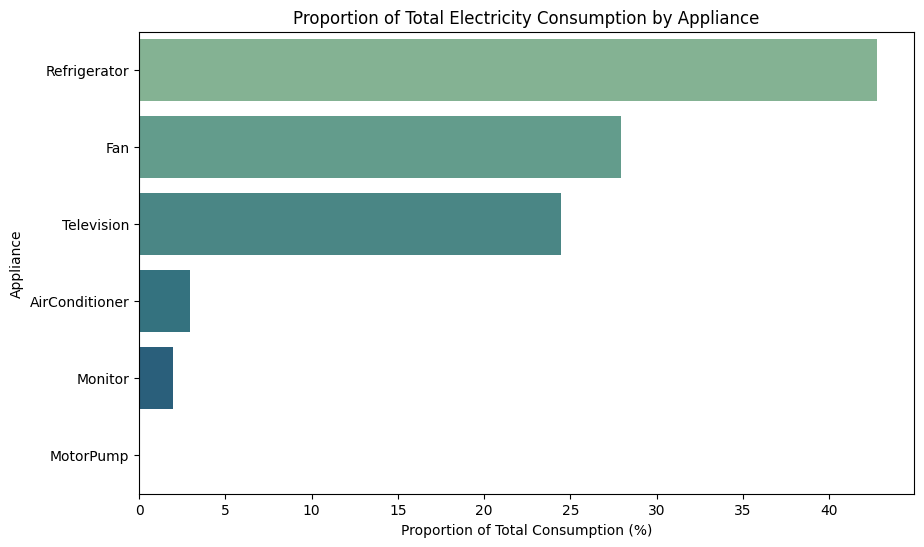

In [58]:
# --------- Objective 5: Total Energy Efficiency ---------

# Calculate the proportion of total electricity consumption by each appliance
df['TotalConsumption'] = df[appliances].sum(axis=1)
appliance_efficiency = df[appliances].sum().reset_index()
appliance_efficiency.columns = ['Appliance', 'Total Consumption (kWh)']
appliance_efficiency['Proportion (%)'] = (appliance_efficiency['Total Consumption (kWh)'] / appliance_efficiency['Total Consumption (kWh)'].sum()) * 100

# Sort by proportion of consumption
appliance_efficiency = appliance_efficiency.sort_values('Proportion (%)', ascending=False)
print("\nProportion of Total Electricity Consumption by Appliance:")
print(appliance_efficiency)

# Plot energy efficiency by appliance
plt.figure(figsize=(10, 6))
sns.barplot(data=appliance_efficiency, x='Proportion (%)', y='Appliance', palette='crest')
plt.title('Proportion of Total Electricity Consumption by Appliance')
plt.xlabel('Proportion of Total Consumption (%)')
plt.ylabel('Appliance')
plt.show()

In [68]:
# seasonal pie chart distribution
    # Pie chart
plt.figure(figsize=(6, 6))
df['season'].value_counts().plot.pie(autopct='%1.1f%%', colors=sns.color_palette('pastel'))
plt.title('Proportion of Season')
plt.ylabel('')
plt.show()

KeyError: 'season'

<Figure size 600x600 with 0 Axes>

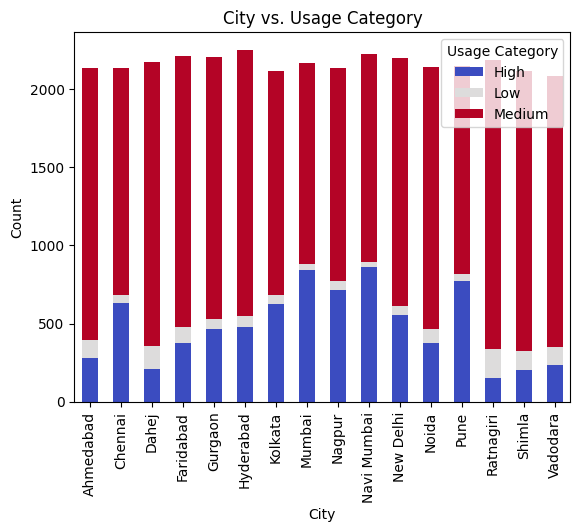

In [69]:
# Stacked bar chart example
pd.crosstab(df['City'], df['UsageCategory']).plot(kind='bar', stacked=True, cmap='coolwarm')
plt.title('City vs. Usage Category')
plt.xlabel('City')
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.legend(title='Usage Category')
plt.show()

In [70]:
# --------- Step 2: Cost Efficiency by Season and City ---------

# Group by city and season to calculate cost efficiency
city_season_analysis = df.groupby(['City', 'season'])[['MonthlyCostPerHour', 'TariffEfficiency']].mean().reset_index()
print("\nCost Efficiency by City and Season:")
print(city_season_analysis)

# Plot cost efficiency by season for top cities
plt.figure(figsize=(14, 8))
sns.barplot(data=city_season_analysis, x='season', y='MonthlyCostPerHour', hue='City', palette='viridis')
plt.title('Monthly Cost Per Hour by City and Season', fontsize=16)
plt.xlabel('Season', fontsize=12)
plt.ylabel('Monthly Cost Per Hour ($)', fontsize=12)
plt.legend(title='City', fontsize=10, loc='upper right')
plt.grid(True)
plt.show()

KeyError: 'season'